# Part 1: N-gram Language Model

## Plan

### Step 1: Load Data

- Load `Salesforce/wikitext` (wikitext-2-raw-v1) from HuggingFace
- Dataset link: https://huggingface.co/datasets/Salesforce/wikitext
- Load train and test splits separately

### Step 2: Preprocessing

- Lowercase all text
- Remove punctuation
- Tokenize into words
- Skip empty lines
- Add (N-1) `<s>` start tokens and 1 `</s>` end token per sentence
- Extract vocabulary (all unique words from training set)

### Step 3: Extract N-grams

- Extract unigrams, bigrams, and trigrams from the training corpus

### Step 4: Training (Learning Phase)

- Count N-gram frequencies
- Compute probabilities with Add-1 (Laplace) smoothing:

  if bigram
  $$P(w_2\mid w_1) = \frac{\operatorname{count}(w_1,w_2) + 1}{\operatorname{count}(w_1) + |V|}$$

### Step 5: Evaluation (Testing Phase)

- Apply same preprocessing to test set
- Compute log probability of the test corpus
- Calculate perplexity for unigram, bigram, and trigram models
  - $$\text{PP}(W) = 2^{-\frac{1}{N} \sum_{i=1}^N \log_2 P(w_i\mid \text{history})}$$
- Compare results


## Perplexity

Perplexity quantifies how well a model predicts a corpus: the inverse geometric mean probability of the token sequence.

$$
\text{PP}(W) = \sqrt[N]{\frac{1}{P(w_1^N)}} = P(w_1^N)^{-\frac{1}{N}}
$$

Using the **chain rule**, this expands to:

$$
\text{PP}(W) = \sqrt[N]{\prod_{i=1}^{N} \frac{1}{P(w_i \mid w_1^{i-1})}}
$$

For a bigram model this reduces to:

$$
\text{PP}(W) = \sqrt[N]{\prod_{i=1}^{N} \frac{1}{P(w_i \mid w_{i-1})}}
$$

Here $N$ is the number of tokens in the corpus (excluding `<s>` start tokens; including `</s>` tokens, since `<s>` is only context and never predicted). Lower perplexity indicates a better model.


# Part 1: N-gram Language Model

## Step 1: Load Data

Dataset: `Salesforce/wikitext` (wikitext-2-raw-v1)  
Link: https://huggingface.co/datasets/Salesforce/wikitext


!pip install datasets
(to install all datasets of hugging face and the access wikitext)


In [11]:
!pip install datasets


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


https://huggingface.co/docs/datasets/v1.1.3/loading_datasets.html


In [12]:
from datasets import load_dataset

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
print(dataset)
train_data = dataset["train"]
test_data = dataset["test"]
val_data = dataset["validation"]

print(f"Train size: {len(train_data)}")
print(f"Test size:  {len(test_data)}")
print(dataset["test"]["text"])
print(dataset["train"][1])
print(dataset["train"][1]["text"])
dataset["train"].to_pandas().head(5)
# we can see we have empty lines in our data
# as well as \n and = signs

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})
Train size: 36718
Test size:  4358
Column(['', ' = Robert Boulter = \n', '', ' Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in 2000 . This was followed by a starring role in the play Herons written by Simon Stephens , which was performed in 2001 at the Royal Court Theatre . He had a guest role in the television series Judge John Deed in 2002 . In 2004 Boulter landed a role as " Craig " in the episode " Teddy \'s Story " of the television series The Long Firm ; he starred alongside actors Mark Strong and Derek Jacobi . He was cast in the 2005 theatre productions of the Philip Ridley play Mercury Fur , which was performed at the Drum Theatre in P

,text
0,
1,= Valkyria Chronicles III = \n
2,
3,Senjō no Valkyria 3 : Unrecorded Chronicles (...
4,"The game began development in 2010 , carrying..."


## Step 2: Preprocessing

## Start and End tokens

why start tokens ? we must add (n-1) start tokens to match the n-gram model we are making and we have to add an end token to normalize the probability over all sequences length and for the model to learn where to stop
**Why Start and End Tokens?**

We add (n-1) start tokens `<s>` to match the n-gram model structure, and 1 end token `</s>` to:only learns word-to-word transitions:

1. Normalize probability over all sequence lengths
2. Enable the model to learn where to stope)

**Example: Importance of End Token**

Without `</s>`:)

- The model only learns word-to-word transitions: P(cat | the), P(sat | cat), P(on | sat)
- It has no idea when to stop and could generate indefinitelyen to stop. It could go on forever.

With `</s>`:

- `</s>` becomes a regular vocabulary wordl learns:
- The model learns both continuation and stopping probabilities:
  - P(cat | the) = 0.3 P(cat | the) = 0.3
  - P(sat | cat) = 0.4
  - P(</s> | sat) = 0.2 ← probability of **stopping**
  - P(on | sat) = 0.3 ← probability of **continuing**

At every position, the model decides: "Should I stop here or keep going?"
P(sat | cat) = 0.4

P(</s> | sat) = 0.2 ← probability of STOPPING after "sat"

P(on | sat) = 0.3 ← probability of CONTINUING after "sat"

So at every position the model is asking:

"Should I stop here or keep going?"


## Step 2: Preprocessing

We apply the following steps to every line in the corpus:

| Step                           | Why                                    |
| ------------------------------ | -------------------------------------- |
| Remove `@,@` / `@-@` artifacts | WikiText-specific tokenization noise   |
| Lowercase                      | Treat `The` and `the` as the same word |
| Remove punctuation             | Reduce sparsity                        |
| Tokenize by whitespace         | Simple word-level tokens               |
| Skip empty lines               | WikiText has many blank/header lines   |
| Add `<s>` × (n−1) + `</s>`     | Context alignment + stop-probability   |
| Build vocabulary + `<UNK>`     | Handle unseen words at test time       |


In [13]:
from collections import Counter


def clean_line(text):
    # 1.2. takes a sentence makes it to lower and remove any thing other than alphanumerics
    text = text.lower()
    # looping over all characters in text if any other character rather than alphanumeric replaced by empty space
    text = "".join(ch if ch.isalpha() or ch == " " else " " for ch in text)
    return text.split()
    # returns an array with all the words in one line after cleaning


def build_corpus(X, n):
    # X is the training, validation or test set
    """
    Convert a HuggingFace dataset split into a list of token-lists.
    Each sentence is wrapped with (n-1) <s> tokens and one </s> token.

    n=1 → no <s> added  (unigram has no context)
    n=2 → ['<s>', w1, w2, ..., '</s>']
    n=3 → ['<s>', '<s>', w1, w2, ..., '</s>']
    """
    corpus = []
    # X is a column with all the documents/sentences we have
    # each row represents a line/sentence (document)
    for row in X:
        # dataset["train"]-> a column with all sentences
        # dataset["train"][0] accessing a specific row and that is what the loop does (row is a dictionary that has a key named text)
        tokens = clean_line(row["text"])
        if not tokens:  # skip empty / header lines
            continue
        # add start and end tokens
        sentence = ["<s>"] * (n - 1) + tokens + ["</s>"]
        corpus.append(sentence)
    return corpus
    # corpus = [


#     ['<s>', '<s>', 'robert', 'boulter', 'is', 'an', 'english', 'actor', '</s>'],
#     ['<s>', '<s>', 'the', 'film', 'was', 'released', 'in', 'london', '</s>'],
#     ['<s>', '<s>', 'he', 'won', 'several', 'awards', '</s>'],
#     ...] list of lists (each list is a collection of words that is found in the sentence)


def build_vocab(train_corpus, min_freq=2):
    # build vocab from training corpus and add the <s></s> and <UNK> unknown
    # for words that appeared less than min frequency (maybe it is noise we are not sure so we dont add it to the vocab
    # this helps to reduce the vocab size)

    # collect all words in a list then pass it to counter
    # to count the occurence of each word
    all_tokens = []
    for sentence in train_corpus:  # loop over sentences
        for word in sentence:  # loop over words in that sentence
            all_tokens.append(word)
    counter = Counter(all_tokens)  # returns a dictionary wordd:count

    # vocab is a set of all unique words we have in the corpus
    vocab = {"<s>", "</s>", "<UNK>"}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab.add(word)

    return vocab


# dropping all words that are out of vocab whether from the train or test data sets
def apply_unk(corpus, vocab):
    # Replace every token not in vocab with <UNK>.
    # Applied to BOTH train and test corpora after vocab is built from train.
    new_corpus = []
    for sentence in corpus:
        new_sentence = []
        for word in sentence:
            if word in vocab:
                new_sentence.append(word)
            else:
                # mark it as unknown so we won't calculate probability for it we will ignore its existence (word out of vocab)
                new_sentence.append("<UNK>")
        new_corpus.append(new_sentence)
    return new_corpus


# n-gram model (change n)
N = 3

# building train and test corpus
train_corpus = build_corpus(train_data, n=N)
test_corpus = build_corpus(test_data, n=N)

# building vocabulary from training corpus
vocab = build_vocab(train_corpus, min_freq=2)

# droping unknown words that isnt in the vocab
train_corpus = apply_unk(train_corpus, vocab)
test_corpus = apply_unk(test_corpus, vocab)


print(f"  N (gram size)       : {N}")
print(f"  Train sentences     : {len(train_corpus):,}")
print(f"  Test  sentences     : {len(test_corpus):,}")
print(f"  Vocabulary size |V| : {len(vocab):,}")
print(f"\nSample train sentence:")
print(train_corpus[5])
print(f"\nSample test  sentence:")
print(test_corpus[5])

  N (gram size)       : 3
  Train sentences     : 23,694
  Test  sentences     : 2,889
  Vocabulary size |V| : 37,180

Sample train sentence:
['<s>', '<s>', 'as', 'with', 'previous', 'valkyira', 'chronicles', 'games', 'valkyria', 'chronicles', 'iii', 'is', 'a', 'tactical', 'role', 'playing', 'game', 'where', 'players', 'take', 'control', 'of', 'a', 'military', 'unit', 'and', 'take', 'part', 'in', 'missions', 'against', 'enemy', 'forces', 'stories', 'are', 'told', 'through', 'comic', 'book', 'like', 'panels', 'with', 'animated', 'character', 'portraits', 'with', 'characters', 'speaking', 'partially', 'through', 'voiced', 'speech', 'bubbles', 'and', 'partially', 'through', '<UNK>', 'text', 'the', 'player', 'progresses', 'through', 'a', 'series', 'of', 'linear', 'missions', 'gradually', 'unlocked', 'as', 'maps', 'that', 'can', 'be', 'freely', '<UNK>', 'through', 'and', 'replayed', 'as', 'they', 'are', 'unlocked', 'the', 'route', 'to', 'each', 'story', 'location', 'on', 'the', 'map', 'vari

# STEP 3: Extract N-grams

# Step 4: count their frequencies


- The idea of n-grams can be implemented using a sliding window of size n over the sentence to extract n consecutive words (forming an n-gram)

- Every step we have to count two things:

1. ngram_Counts (window of size n) count of every n-gram in the training corpus in the numerator
2. context Counts (count of every (n-1) prefix) denominator


In [14]:
from collections import defaultdict


# used defaultdict so if the ngram or context arent found by default it will start by count zero
# converting the ngram to a tuple (to immutable so we can use it as a key)
def count_ngrams(corpus, n):
    ngram_counts = defaultdict(int)
    context_counts = defaultdict(int)
    # loop over each sentence start extracting the ngrams in that sentence
    for sentence in corpus:
        # if n=3 we start from index 2
        for i in range(n - 1, len(sentence)):
            # i = 2 -> sentence[2-(3-1):2+1] then (0->2 inclusive)
            # start from then end of the n-gram and we start from the index of (n-1)th word before it
            ngram = tuple(sentence[i - (n - 1) : i + 1])
            # context the prev n-1 words (excluding current word) so we take the ngram except last word
            context = tuple(ngram[0 : len(ngram) - 1])

            ngram_counts[ngram] += 1
            context_counts[context] += 1
    return ngram_counts, context_counts


ngram_counts, context_counts = count_ngrams(train_corpus, N)
print(f"Unique {N}-grams : {len(ngram_counts):,}")
print(f"Unique contexts : {len(context_counts):,}")

print("Some ngrams")
for ngram, count in list(ngram_counts.items())[:5]:
    print(ngram, ":", count)

print("some contexts")
for context, count in list(context_counts.items())[:5]:
    print(context, ":", count)

Unique 3-grams : 1,282,572
Unique contexts : 621,369
Some ngrams
('<s>', '<s>', 'valkyria') : 2
('<s>', 'valkyria', 'chronicles') : 2
('valkyria', 'chronicles', 'iii') : 15
('chronicles', 'iii', '</s>') : 1
('<s>', '<s>', 'senjō') : 1
some contexts
('<s>', '<s>') : 23694
('<s>', 'valkyria') : 2
('valkyria', 'chronicles') : 36
('chronicles', 'iii') : 15
('<s>', 'senjō') : 1


# Step 4: Computing perplexity

Calculate probabilities and add 1 smoothing

$$P(w_i\mid w_1,.....,w_i-1) = \frac{\operatorname{count}(w_1,w_2,....,w_i) + 1}{\operatorname{count}(w_1,....,w_i-1) + |V|}$$

Markov assumption reduces this to depend on the last (n-1) word instead of all of the sequence

- space
- sparsity (diffcuilt to have seen for example all 10-grams most prob you will get many new 10-grams that weren't in the dataset)

$$P(w_i\mid w_i-k,.....,w_i-1) = \frac{\operatorname{count}(w_i-k,w_2,....,w_i) + 1}{\operatorname{count}(w_i-k,....,w_i-1) + |V|}$$


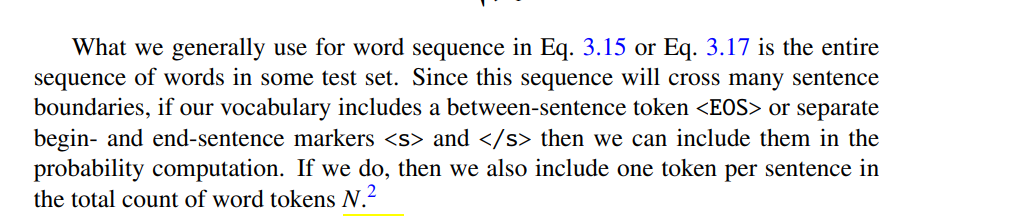

we calculated the probability of end tokens as well as we predict the end of the sentence so we add this the word count N


In [15]:
import math


def compute_perplexity(corpus, ngram_counts, context_counts, vocab, N, k):
    totalLogProp = 0
    word_count = 0  # total number of words perdicted in the test corpus including </s> because the end of a sentence
    # is predicted but the start of a sentence isnt predicted
    for sentence in corpus:
        # loop over words of a sentence but starting from N-1 (skipping the first N-1 start tokens)
        log_sum = 0
        # this loop already skips the start token (so it counts all words skipping the end token)
        for i in range(N - 1, len(sentence)):
            word_count += 1
            ngram = tuple(sentence[i - N + 1 : i + 1])
            context = tuple(ngram[0 : len(ngram) - 1])
            # add 1 smoothing
            wordProp = (ngram_counts[ngram] + k) / (
                context_counts[context] + k * len(vocab)
            )
            logProp = math.log(
                wordProp
            )  # to avoid underflow because the probability numbers are too small
            log_sum += logProp
        totalLogProp += log_sum  # the probability of the whole test corpus assuming the documents in the corpus are independent
    perplexity = math.exp(-1 / word_count * totalLogProp)
    return perplexity

# HyperParamater tuning:

- (N-grams,add k smoothing) , tune k and n on the validation set and tuning UNK Threshold


In [16]:
N_values = [1, 2, 3, 4]
k_values = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
min_freq_values = [1, 2, 3, 5]

best_pp = float("inf")
best_N = None
best_k = None
best_minFreq = None
results = []  # store all (N, k, val_pp) for the table

print("Tuning on VALIDATION set ...")
print(f"{'N':>4}  {'k':>7} {'Min Frequnecy':>12} {'Val PP':>12}")
print("-" * 28)


for min_freq in min_freq_values:
    for N in N_values:
        # rebuild corpus and counts for this N
        train_corpus = build_corpus(train_data, N)
        val_corpus = build_corpus(val_data, N)
        vocab = build_vocab(train_corpus, min_freq=min_freq)
        train_corpus = apply_unk(train_corpus, vocab)
        val_corpus = apply_unk(val_corpus, vocab)
        ngram_counts, context_counts = count_ngrams(train_corpus, N)

        for k in k_values:
            val_pp = compute_perplexity(
                val_corpus, ngram_counts, context_counts, vocab, N, k
            )
            print(f"{N:>4}  {k:>7}  {min_freq:>12}  {val_pp:>12.2f}")

            if val_pp < best_pp:
                best_pp = val_pp
                best_N = N
                best_k = k
                best_minFreq = min_freq

print("-" * 28)
print(
    f"\nBest on validation: N={best_N}, k={best_k}  minfreq={best_minFreq} →  PP={best_pp:.2f}"
)

# Final evaluation — run ONCE on test set with best (N, k)

print("\nEvaluating best model on TEST set ")
train_corpus = build_corpus(train_data, best_N)
test_corpus = build_corpus(test_data, best_N)
vocab = build_vocab(train_corpus, min_freq=best_minFreq)
train_corpus = apply_unk(train_corpus, vocab)
test_corpus = apply_unk(test_corpus, vocab)
ngram_counts, context_counts = count_ngrams(train_corpus, best_N)

test_pp = compute_perplexity(
    test_corpus, ngram_counts, context_counts, vocab, best_N, best_k
)

print(f"\n{'─'*40}")
print(f"  Best N  : {best_N}")
print(f"  Best k  : {best_k}")
print(f"  Best minFreq  : {best_minFreq}")
print(f"  Test PP : {test_pp:.2f}")
print(f"{'─'*40}")

Tuning on VALIDATION set ...
   N        k Min Frequnecy       Val PP
----------------------------
   1   0.0001             1       2558.03
   1    0.001             1       2363.17
   1     0.01             1       2183.27
   1      0.1             1       2018.34
   1      0.5             1       1917.40
   1      1.0             1       1884.64
   2   0.0001             1       2933.07
   2    0.001             1       1950.36
   2     0.01             1       1980.40
   2      0.1             1       3289.89
   2      0.5             1       5920.19
   2      1.0             1       7923.78
   3   0.0001             1      13203.59
   3    0.001             1      11217.79
   3     0.01             1      14000.09
   3      0.1             1      21852.98
   3      0.5             1      31189.63
   3      1.0             1      36021.88
   4   0.0001             1      33588.54
   4    0.001             1      33533.11
   4     0.01             1      38043.22
   4      0.1      

# Save and load data

- using pickling we start saving and loading data
  it takes pythin objects and convert it into some form where it can be written in a file

then we can read this file back we can get our list/tuple/dictionary back
after training and have the counts of n-grams and (n-1) grams and tuning we save that model (counts) and then restore it for inference and generation of word perdiction


In [17]:
import pickle

# Saves: ngram_counts, context_counts, vocab, N, k, min_freq


def save_model(ngram_counts, context_counts, vocab, N, k, min_freq, path="ngram.pkl"):
    model = {
        "ngram_counts": dict(ngram_counts),  # tuple keys → fine for pickle
        "context_counts": dict(context_counts),
        "vocab": vocab,  # set
        "N": N,
        "k": k,
        "min_freq": min_freq,
    }
    with open("ngram.pkl", "wb") as file:
        # pass to it to the object to be pickled and the file we read from
        pickle.dump(model, file)
    print(f"Model saved to '{path}'")
    print(f"  N={N}  k={k}  min_freq={min_freq}  |V|={len(vocab):,}")
    print(f"  unique {N}-grams : {len(ngram_counts):,}")


# LOADING


def load_model(path="ngram.pkl"):
    with open(path, "rb") as file:
        model = pickle.load(file)
    # restore as defaultdict(int) so unseen keys return 0
    model["ngram_counts"] = defaultdict(int, model["ngram_counts"])
    model["context_counts"] = defaultdict(int, model["context_counts"])
    print(f"Model loaded from '{path}'")
    print(
        f"  N={model['N']}  k={model['k']}  min_freq={model['min_freq']}  |V|={len(model['vocab']):,}"
    )
    return model

In [18]:
save_model(ngram_counts, context_counts, vocab, best_N, best_k, best_minFreq)

Model saved to 'ngram.pkl'
  N=2  k=0.01  min_freq=5  |V|=19,946
  unique 2-grams : 599,197


In [19]:
load_model()

Model loaded from 'ngram.pkl'
  N=2  k=0.01  min_freq=5  |V|=19,946


{'ngram_counts': defaultdict(int,
             {('<s>', 'valkyria'): 2,
              ('valkyria', 'chronicles'): 36,
              ('chronicles', 'iii'): 15,
              ('iii', '</s>'): 8,
              ('<s>', 'senjō'): 1,
              ('senjō', 'no'): 5,
              ('no', 'valkyria'): 5,
              ('valkyria', '<UNK>'): 6,
              ('<UNK>', 'chronicles'): 5,
              ('chronicles', 'japanese'): 1,
              ('japanese', '<UNK>'): 22,
              ('<UNK>', 'lit'): 14,
              ('lit', 'valkyria'): 4,
              ('valkyria', 'of'): 4,
              ('of', 'the'): 17466,
              ('the', 'battlefield'): 31,
              ('battlefield', 'commonly'): 1,
              ('commonly', 'referred'): 8,
              ('referred', 'to'): 203,
              ('to', 'as'): 114,
              ('as', 'valkyria'): 1,
              ('iii', 'outside'): 1,
              ('outside', 'japan'): 6,
              ('japan', 'is'): 1,
              ('is', 'a'): 1421,
   

## Part 1.4: Inference and Text Generation


### Objective
The goal of this section is to implement a robust inference function that utilizes the trained N-gram model parameters saved . The function demonstrates the model's ability to predict and generate text sequentially based on a user-provided prompt.

### Implementation Details
The inference process follows these logical steps:

* **Model Loading**: The function interfaces with the `load_model` utility to retrieve the `ngram_counts`, `vocabulary`, and configuration parameters (N, k, min_freq) from the disk.
* **Context Windowing**: Based on the $N$ value (e.g., $N=2$ for bigrams), the model identifies the last $N-1$ tokens of the current sequence to serve as the context for the next prediction.
* **Greedy Search Logic**: To satisfy the requirement of generating the "next" token, the model calculates the frequency of all words in the vocabulary following the current context using the `ngram_counts`.
* **Handling Repetition and `<UNK>`**: Because the `<UNK>` token often has the highest statistical frequency in the WikiText dataset, the inference function includes a filter to skip unknown tokens, ensuring the generated text remains human-readable.
![Screenshot 2026-03-05 151817.png](<attachment:Screenshot 2026-03-05 151817.png>)
* **Termination Criteria**: Generation continues until one of two conditions is met:
    * The model predicts the specific `</end>` .
    * The sequence reaches the `max_tokens` .

### Observations on Model Behavior


During testing, we observed that low $N$ values (like $N=2$) can lead to "Greedy Loops" where the model repeats common phrases (e.g., *"the first time the first time"*). This is a known limitation of Markovian models with short memory spans.
![Screenshot 2026-03-05 151944.png](<attachment:Screenshot 2026-03-05 151944.png>)
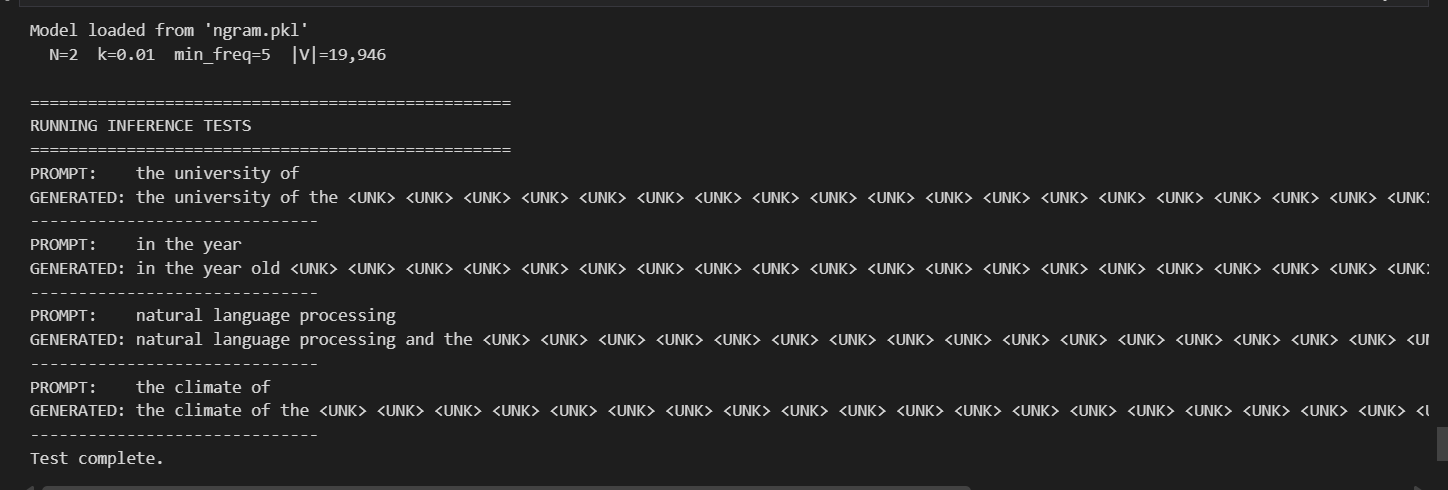
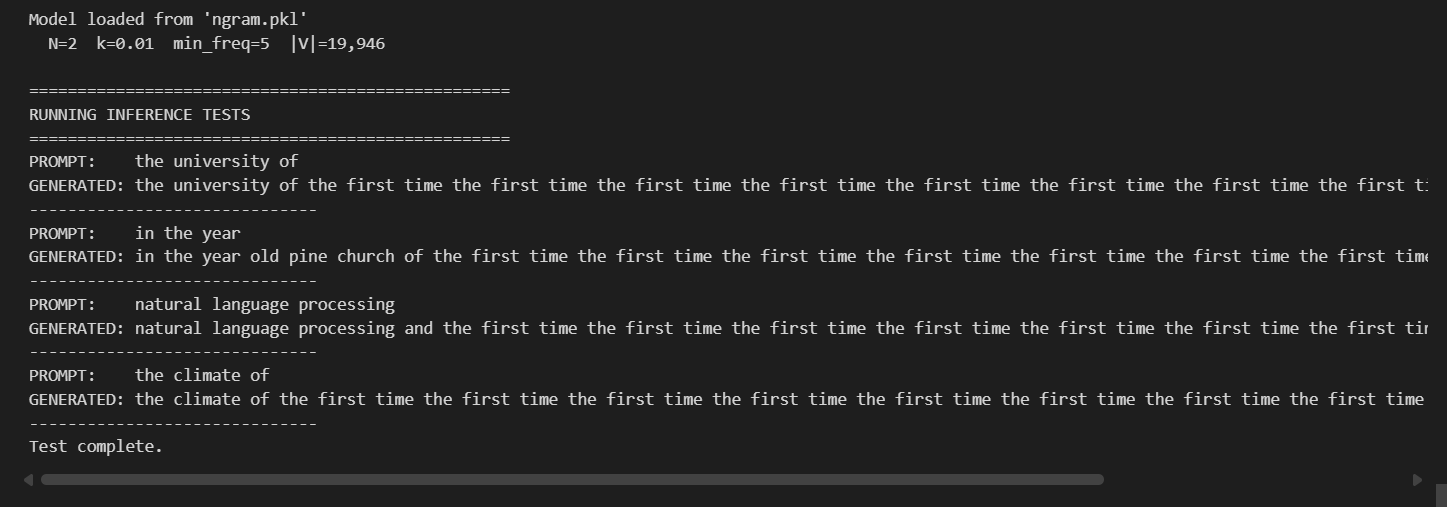

In [30]:
import random

def generate_text(model, prompt, max_tokens=20, temperature=0.7):
    ngram_counts = model["ngram_counts"]
    vocab = list(model["vocab"])
    N = model["N"]
    
    generated_tokens = prompt.lower().split()
    
    for _ in range(max_tokens):
        context = tuple(generated_tokens[-(N-1):])
        
        # Get all possible next words and their counts
        candidates = []
        counts = []
        
        for word in vocab:
            if word == "<UNK>": continue # Filter out the noise
            
            count = ngram_counts[context + (word,)]
            if count > 0:
                candidates.append(word)
                counts.append(count)
        
        if not candidates:
            break
            
        # pick from the best options instead of just the #1 option
        best_indices = np.argsort(counts)[-5:] # Look at top 5
        top_candidates = [candidates[i] for i in best_indices]
        top_counts = [counts[i] for i in best_indices]
        
        next_word = random.choices(top_candidates, weights=top_counts)[0]
        generated_tokens.append(next_word)
        
        if next_word == "</end>": # Proper termination 
            break
            
    return " ".join(generated_tokens)

In [31]:
# Load the model 
try:
    my_model = load_model("ngram.pkl") 
except FileNotFoundError:
    print("Error: 'ngram.pkl' not found ")

# Define test prompts (Choose phrases likely found in WikiText)
test_prompts = [
    "the university of",
    "in the year",
    "natural language processing",
    "the climate of"
]

print("\n" + "="*50)
print("RUNNING INFERENCE TESTS")
print("="*50)

# Generate and display results
for prompt in test_prompts:
    # We use max_tokens=30 to ensure we don't exceed Colab limits 
    generated_text = generate_text(my_model, prompt, max_tokens=30) 
    
    print(f"PROMPT:    {prompt}")
    print(f"GENERATED: {generated_text}")
    print("-" * 30)

print("Test complete.")

Model loaded from 'ngram.pkl'
  N=2  k=0.01  min_freq=5  |V|=19,946

RUNNING INFERENCE TESTS
PROMPT:    the university of
GENERATED: the university of the game and the first time and a new jersey state of the th century in the first time of the first time in a new england and the first
------------------------------
PROMPT:    in the year
GENERATED: in the year and in and his father of the same time the song is a result of the song s death the first time the song in the first time and the
------------------------------
PROMPT:    natural language processing
GENERATED: natural language processing and the first time to a new york city of the first time of their first two years of the first time of the first time of the first time
------------------------------
PROMPT:    the climate of
GENERATED: the climate of the song in a few months after his first time to the first time of the first time the first time the first time of the game was the th
------------------------------
Test complete